<a href="https://colab.research.google.com/github/kaveeshahq/research-project/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib shap joblib imbalanced-learn xgboost lightgbm

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
import shap

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
DATA_PATH = "/content/winequality-white (1).csv"   # <-- your uploaded dataset
MODEL_OUT = "rf_wine_regressor.joblib"
SHAP_OUT = "shap_summary.png"

In [ ]:
print("Loading dataset...")
df = pd.read_csv('winequality-white (1).csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)
print("\nLabel distribution:")

Loading dataset...
Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)

Label distribution:


In [ ]:
df = df.copy()
# Example engineered feature — acid ratio (interpretable)
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

In [ ]:
df = df.copy()
# Example engineered feature — acid ratio (interpretable)
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

In [ ]:
TARGET = 'quality'
X = df.drop(columns=[TARGET])
y = df[TARGET].values

In [ ]:
bins = [0, 4, 5, 6, 7, 11]   # adjust bins if necessary
y_binned = pd.cut(y, bins=bins, labels=False, include_lowest=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binned
)
print("Train / Test sizes:", X_train.shape, X_test.shape)

Train / Test sizes: (3918, 12) (980, 12)


In [ ]:
pipe = Pipeline([
    #('scaler', StandardScaler()),   # RandomForest doesn't require scaling
    ('rf', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

In [ ]:
def rmse_cv(model, X, y, cv):
    neg_mse = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    rmse = np.sqrt(-neg_mse)
    return rmse

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Running baseline 5-fold CV (this may take a moment)...")
base_rmse = rmse_cv(pipe, X_train, y_train, cv)
print("Baseline CV RMSE per fold:", np.round(base_rmse, 3))
print("Baseline CV RMSE mean ± std:", np.round(base_rmse.mean(), 3), "±", np.round(base_rmse.std(), 3))

Running baseline 5-fold CV (this may take a moment)...
Baseline CV RMSE per fold: [0.633 0.627 0.648 0.596 0.611]
Baseline CV RMSE mean ± std: 0.623 ± 0.018


In [ ]:
param_dist = {
    "rf__n_estimators": [100, 200, 400, 800],
    "rf__max_depth": [None, 6, 10, 20, 40],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ['auto', 'sqrt', 0.3, 0.5]
}
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Starting RandomizedSearchCV...")
rs.fit(X_train, y_train)
print("RandomizedSearchCV done. Best params:")
print(rs.best_params_)

best_model = rs.best_estimator_

Starting RandomizedSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomizedSearchCV done. Best params:
{'rf__n_estimators': 800, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': None}


In [ ]:
y_pred_test = best_model.predict(X_test)
# Calculate Mean Squared Error first
mse = mean_squared_error(y_test, y_pred_test)
# Then calculate RMSE by taking the square root of MSE
test_rmse = np.sqrt(mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print("\nTest set performance:")
print("RMSE:", round(test_rmse, 3))
print("MAE:", round(test_mae, 3))
print("R2:", round(test_r2, 3))


Test set performance:
RMSE: 0.623
MAE: 0.448
R2: 0.507


In [ ]:
rf = best_model.named_steps['rf']
feat_names = X.columns.tolist()
fi = pd.DataFrame({'feature': feat_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop features by model importance:")
print(fi.head(15))

# permutation importance (robust)
print("\nComputing permutation importance (may take a while)...")
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({'feature': feat_names, 'perm_mean': perm.importances_mean}).sort_values('perm_mean', ascending=False)
print(perm_df.head(15))


Generating SHAP values (TreeExplainer)...
Saved SHAP summary to: shap_summary.png


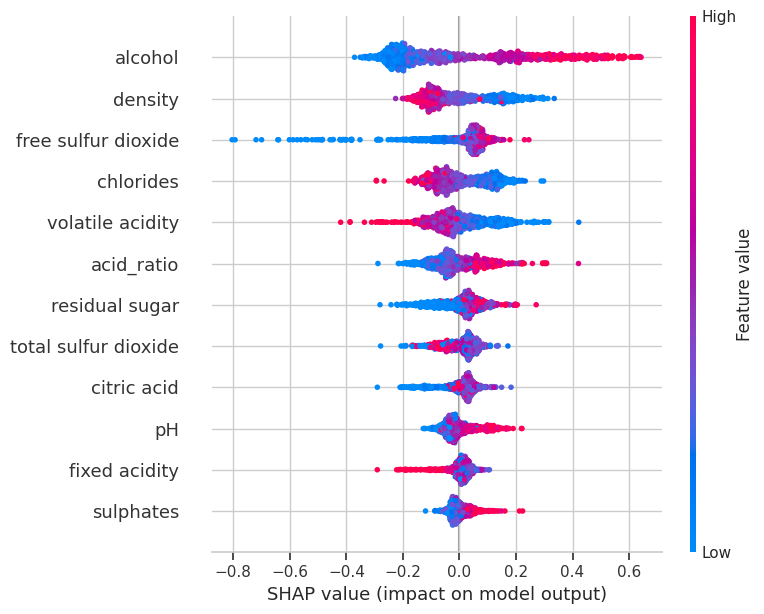

In [ ]:
print("\nGenerating SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(rf)
# Use all test rows or subsample for speed
X_shap = X_test if X_test.shape[0] <= 1000 else X_test.sample(1000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot (saved to file)
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.savefig(SHAP_OUT, dpi=200)
print("Saved SHAP summary to:", SHAP_OUT)

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
top_feature = fi.iloc[0]['feature']
print("Top feature for PDP:", top_feature)
_ = PartialDependenceDisplay.from_estimator(best_model, X_test, [top_feature], kind='average', grid_resolution=50)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump({
    "pipeline": best_model,
    "feature_names": feat_names,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}, MODEL_OUT)
print("Saved pipeline and metadata to:", MODEL_OUT)

In [ ]:
sample = X_test.sample(5, random_state=RANDOM_STATE)
preds = best_model.predict(sample)
print("\nSample predictions:")
print(pd.concat([sample.reset_index(drop=True), pd.Series(preds, name='pred_quality')], axis=1))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lin_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lin_pipe.fit(X_train, y_train)
lin_pred = lin_pipe.predict(X_test)

print("Linear Regression")
print("RMSE:", mean_squared_error(y_test, lin_pred, squared=False))
print("MAE:", mean_absolute_error(y_test, lin_pred))
print("R2:", r2_score(y_test, lin_pred))
